In [306]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 1) MORTALITY DATA
# -------------------------

mortality = pd.read_excel(
    "data/UNIGME-2025-UNICEFRegion-Rates-Deaths-Sex-specific-5-to-24.xlsx",
    sheet_name="20q5, 10q10",
    skiprows=14
)

mortality.columns = mortality.columns.str.strip()

mortality = mortality[["Region", "Sex", "Year", "Median"]]

mortality = mortality.rename(columns={
    "Median": "mort_median_5_24"
})

mortality["mort_median_5_24"] = pd.to_numeric(
    mortality["mort_median_5_24"],
    errors="coerce"
)

mortality = mortality.groupby(["Region", "Year"])["mort_median_5_24"].mean().reset_index()


# -------------------------
# 2) HDI DATA
# -------------------------

hdi = pd.read_excel(
    "data/HDR25_Statistical_Annex_HDI_Table.xlsx",
    skiprows=4,
    usecols="B:C"
)

hdi.columns = ["Country", "HDI"]
hdi = hdi.iloc[2:].reset_index(drop=True)

hdi["Country"] = hdi["Country"].astype(str).str.strip()
hdi["HDI"] = pd.to_numeric(hdi["HDI"], errors="coerce")


# -------------------------
# 3) ECONOMIC DATA
# -------------------------

econ = pd.read_excel(
    "data/19-Economic-Indicators-SOWC2025-1.xlsx",
    skiprows=6,
    header=None,
    usecols=[1, 6, 8]
)

econ.columns = ["Country", "health_spending", "education_spending"]
econ = econ.iloc[1:].reset_index(drop=True)

econ["Country"] = econ["Country"].astype(str).str.strip()
econ["health_spending"] = pd.to_numeric(econ["health_spending"], errors="coerce")
econ["education_spending"] = pd.to_numeric(econ["education_spending"], errors="coerce")


# -------------------------
# 4) REGION MAPPING
# -------------------------

mapping = pd.read_excel("data/JME_Regional-Classifications.xlsx")
mapping.columns = mapping.columns.str.strip()

mapping = mapping[["Country", "UNICEF Region"]]
mapping["Country"] = mapping["Country"].astype(str).str.strip()

region_map = {
    "EAPRO": "East Asia and Pacific",
    "ECA": "Europe and Central Asia",
    "LACRO": "Latin America and Caribbean",
    "MENA": "Middle East and North Africa",
    "ROSA": "South Asia",
    "SSA": "Sub-Saharan Africa"
}


# -------------------------
# 5) MERGE HDI + ECON WITH REGION
# -------------------------

hdi = hdi.merge(mapping, on="Country", how="left")
hdi = hdi.rename(columns={"UNICEF Region": "Region"})
hdi["Region"] = hdi["Region"].replace(region_map)

econ = econ.merge(mapping, on="Country", how="left")
econ = econ.rename(columns={"UNICEF Region": "Region"})
econ["Region"] = econ["Region"].replace(region_map)


# -------------------------
# 6) REGION-LEVEL AVERAGES
# -------------------------

hdi_region = hdi.groupby("Region")["HDI"].mean().reset_index()

econ_region = econ.groupby("Region")[["health_spending", "education_spending"]].mean().reset_index()


# -------------------------
# 7) FINAL DATAFRAME
# -------------------------

df = mortality.merge(hdi_region, on="Region", how="left")
df = df.merge(econ_region, on="Region", how="left")

df = df.dropna().reset_index(drop=True)

df.head()

,Region,Year,mort_median_5_24,HDI,health_spending,education_spending
0,East Asia and Pacific,1990,18.477822,0.735857,4.563424,4.522219
1,East Asia and Pacific,1991,18.001312,0.735857,4.563424,4.522219
2,East Asia and Pacific,1992,17.444175,0.735857,4.563424,4.522219
3,East Asia and Pacific,1993,16.978292,0.735857,4.563424,4.522219
4,East Asia and Pacific,1994,16.549464,0.735857,4.563424,4.522219


In [307]:
df.isnull().sum()

Region                0
Year                  0
mort_median_5_24      0
HDI                   0
health_spending       0
education_spending    0
dtype: int64

In [321]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

X = df[["HDI", "health_spending", "education_spending"]]
y = df["mort_median_5_24"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=10)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 58.94785944236975
R2: 0.787287678255176


In [310]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[["HDI", "health_spending", "education_spending"]]
y = df["mort_median_5_24"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_linear))
print("Linear Regression R2:", r2_score(y_test, y_pred_linear))

Linear Regression MSE: 98.88599046410343
Linear Regression R2: 0.6431716296633285


In [311]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [312]:
# KNN hyperparameter tuning

k_values = range(1, 15)
r2_scores = []

for k in k_values:
    knn_temp = KNeighborsRegressor(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    y_pred_temp = knn_temp.predict(X_test_scaled)
    r2_scores.append(r2_score(y_test, y_pred_temp))

best_k = list(k_values)[np.argmax(r2_scores)]

print("Best k:", best_k)
print("Best R2:", max(r2_scores))

# Final KNN model using selected k
knn = KNeighborsRegressor(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN MSE:", mean_squared_error(y_test, y_pred_knn))
print("KNN R2:", r2_score(y_test, y_pred_knn))

Best k: 11
Best R2: 0.788118644041574
KNN MSE: 58.71757821570546
KNN R2: 0.788118644041574


The optimal number of neighbors (k) was selected empirically by testing values from 1 to 14. The best performance was achieved around k = 10, which was used in the final KNN model.

In [313]:
# =========================
# 1) Train-test split
# =========================
from sklearn.model_selection import train_test_split

X = df[["HDI", "health_spending", "education_spending"]]
y = df["mort_median_5_24"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 2) Scaling (KNN için)
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 3) Linear Regression
# =========================
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

# =========================
# 4) KNN Regression
# =========================
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=10)  # senin seçtiğin k
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

# =========================
# 5) Baseline Model
# =========================
import numpy as np

baseline_pred = np.mean(y_train)
baseline_preds = np.full_like(y_test, baseline_pred)

# =========================
# 6) Metrics için hazır 🎯
# =========================
from sklearn.metrics import mean_squared_error, r2_score

## Machine Learning Model

In this section, Linear Regression and KNN Regression models were used to predict youth mortality rates based on HDI, health spending, and education spending.

Linear Regression was used as a baseline model because it captures the global linear relationship between predictors and the target variable.

KNN Regression was also applied because it can capture more local patterns in the data. Since KNN is distance-based, feature scaling was applied using StandardScaler.

Model performance was evaluated using Mean Squared Error (MSE) and R² score. A lower MSE and higher R² indicate better predictive performance.

In [314]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X_reg = df[["HDI", "health_spending", "education_spending"]]
y_reg = df["mort_median_5_24"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train_reg, y_train_reg)
y_pred_linear = linear_model.predict(X_test_reg)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reg)
X_test_scaled = scaler.transform(X_test_reg)

knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train_scaled, y_train_reg)
y_pred_knn = knn.predict(X_test_scaled)

baseline_pred = np.mean(y_train_reg)
baseline_preds = [baseline_pred] * len(y_test_reg)

print("Ready.")
print("Linear RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_linear)))
print("KNN RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_knn)))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test_reg, baseline_preds)))

print()

print("Linear R2:", r2_score(y_test_reg, y_pred_linear))
print("KNN R2:", r2_score(y_test_reg, y_pred_knn))
print("Baseline R2:", r2_score(y_test_reg, baseline_preds))

Ready.
Linear RMSE: 9.94414352592034
KNN RMSE: 7.677750936463734
Baseline RMSE: 16.655078490960765

Linear R2: 0.6431716296633285
KNN R2: 0.787287678255176
Baseline R2: -0.0009628888535988533


The KNN model outperforms both linear regression and the baseline model, achieving the lowest RMSE and highest R² score.

The predicted vs actual plot shows that most predictions align closely with the ideal diagonal, indicating a good fit.

However, the residual plot suggests increasing variance at higher predicted values, indicating potential heteroscedasticity and limitations in modeling extreme mortality values.

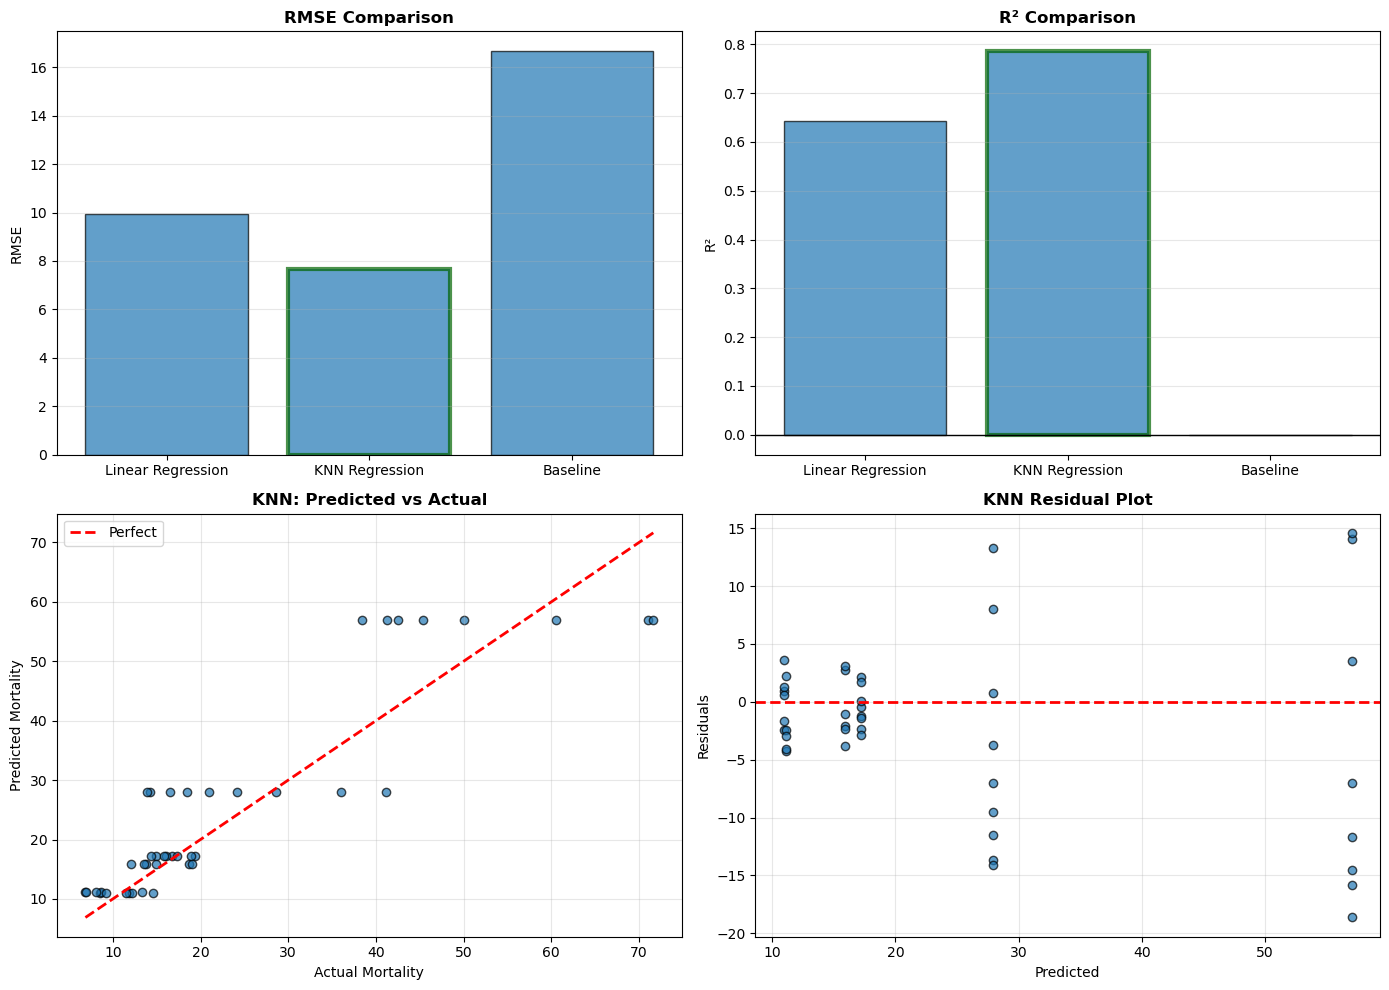

Saved: final_model_dashboard.png


In [315]:
import matplotlib.pyplot as plt

# ---- Metrics ----
models = ["Linear Regression", "KNN Regression", "Baseline"]

rmse_vals = [
    np.sqrt(mean_squared_error(y_test_reg, y_pred_linear)),
    np.sqrt(mean_squared_error(y_test_reg, y_pred_knn)),
    np.sqrt(mean_squared_error(y_test_reg, baseline_preds))
]

r2_vals = [
    r2_score(y_test_reg, y_pred_linear),
    r2_score(y_test_reg, y_pred_knn),
    r2_score(y_test_reg, baseline_preds)
]

# ---- Figure ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -------------------------
# 1) RMSE Comparison
# -------------------------
ax = axes[0, 0]

bars = ax.bar(models, rmse_vals, alpha=0.7, edgecolor="black")

best_idx = rmse_vals.index(min(rmse_vals))
bars[best_idx].set_edgecolor("darkgreen")
bars[best_idx].set_linewidth(3)

ax.set_title("RMSE Comparison", fontweight="bold")
ax.set_ylabel("RMSE")
ax.grid(axis="y", alpha=0.3)


# -------------------------
# 2) R² Comparison
# -------------------------
ax = axes[0, 1]

bars = ax.bar(models, r2_vals, alpha=0.7, edgecolor="black")

best_idx = r2_vals.index(max(r2_vals))
bars[best_idx].set_edgecolor("darkgreen")
bars[best_idx].set_linewidth(3)

ax.set_title("R² Comparison", fontweight="bold")
ax.set_ylabel("R²")
ax.axhline(0, color="black", linewidth=1)
ax.grid(axis="y", alpha=0.3)


# -------------------------
# 3) Predicted vs Actual (KNN)
# -------------------------
ax = axes[1, 0]

ax.scatter(y_test_reg, y_pred_knn, alpha=0.7, edgecolor="black")

min_val = min(y_test_reg.min(), y_pred_knn.min())
max_val = max(y_test_reg.max(), y_pred_knn.max())

ax.plot([min_val, max_val], [min_val, max_val],
        "r--", linewidth=2, label="Perfect")

ax.set_title("KNN: Predicted vs Actual", fontweight="bold")
ax.set_xlabel("Actual Mortality")
ax.set_ylabel("Predicted Mortality")
ax.legend()
ax.grid(alpha=0.3)


# -------------------------
# 4) Residual Plot (KNN)
# -------------------------
ax = axes[1, 1]

residuals = y_test_reg - y_pred_knn

ax.scatter(y_pred_knn, residuals, alpha=0.7, edgecolor="black")
ax.axhline(0, color="red", linestyle="--", linewidth=2)

ax.set_title("KNN Residual Plot", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Residuals")
ax.grid(alpha=0.3)


# ---- Final touches ----
plt.tight_layout()
plt.savefig("final_model_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: final_model_dashboard.png")

In [316]:
baseline_pred = np.mean(y_train)

baseline_preds = [baseline_pred] * len(y_test)

print("Baseline MSE:", mean_squared_error(y_test, baseline_preds))
print("Baseline R2:", r2_score(y_test, baseline_preds))

Baseline MSE: 277.3916395400639
Baseline R2: -0.0009628888535988533


as you see from here, the KNN model performs substantially better than a simple mean baseline, indicating that HDI, health spending, and education spending contain meaningful predictive information about youth mortality.

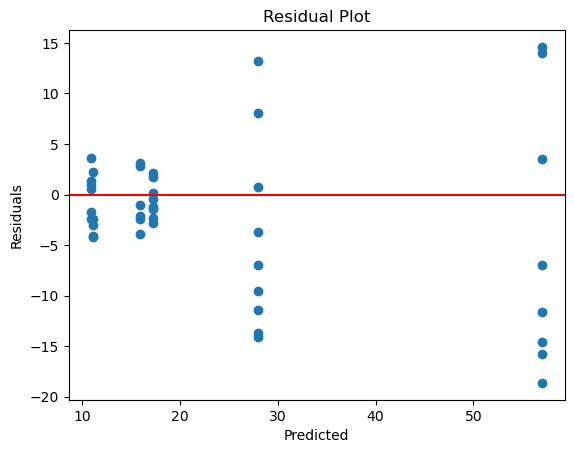

In [317]:
residuals = y_test - y_pred_knn

plt.scatter(y_pred_knn, residuals)
plt.axhline(0, color='red')

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [318]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": linear_model.coef_
})

coef_df

,Feature,Coefficient
0,HDI,-139.899184
1,health_spending,0.285788
2,education_spending,0.379815


In [319]:
df[["HDI", "health_spending", "education_spending"]].corr()

,HDI,health_spending,education_spending
HDI,1.000000,0.888303,0.842585
health_spending,0.888303,1.000000,0.973844
education_spending,0.842585,0.973844,1.000000


In [320]:
# Confusion matrix for the best classifier

best_pred = best_pipe.predict(X_test_c)

ConfusionMatrixDisplay.from_predictions(
    y_test_c,
    best_pred,
    display_labels=["No increase", "Increase"],
    values_format="d"
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

NameError: name 'X_test_c' is not defined

The confusion matrix shows that the model performs well in predicting stable periods (no increase), but struggles to correctly identify increases in mortality.

This suggests that mortality increases are less predictable and may depend on factors not captured in the current feature set.

## Unsupervised Part


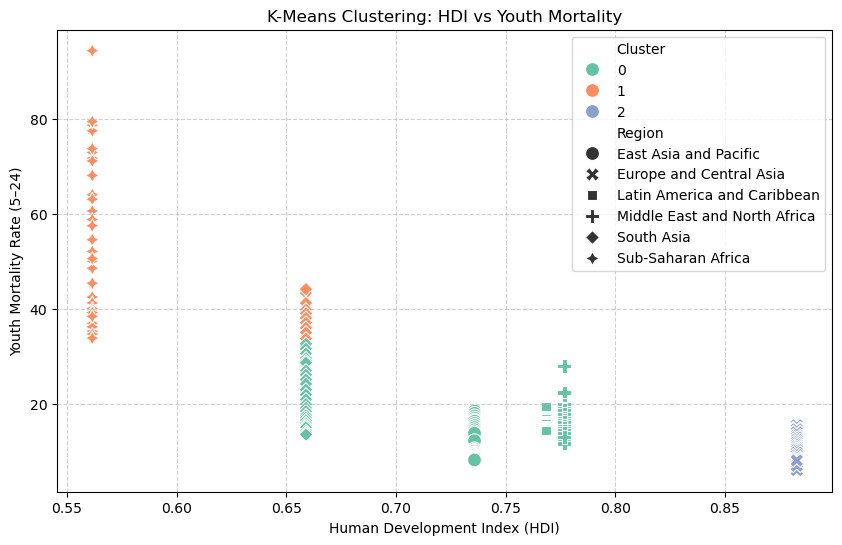

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Feature selection
features = ["HDI", "mort_median_5_24"]
X_cluster = df[features]

# 2) Scaling
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# 3) K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_cluster_scaled)

# 4) Visualization
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="HDI",
    y="mort_median_5_24",
    hue="Cluster",
    style="Region",
    palette="Set2",
    s=100
)

plt.title("K-Means Clustering: HDI vs Youth Mortality")
plt.xlabel("Human Development Index (HDI)")
plt.ylabel("Youth Mortality Rate (5–24)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

K-Means clustering was applied using HDI and youth mortality. Since these variables are measured on different scales, StandardScaler was applied before clustering.

The clustering results show a clear separation between low-HDI/high-mortality observations and high-HDI/low-mortality observations. This supports the idea that development level is strongly associated with both the level and variability of youth mortality.

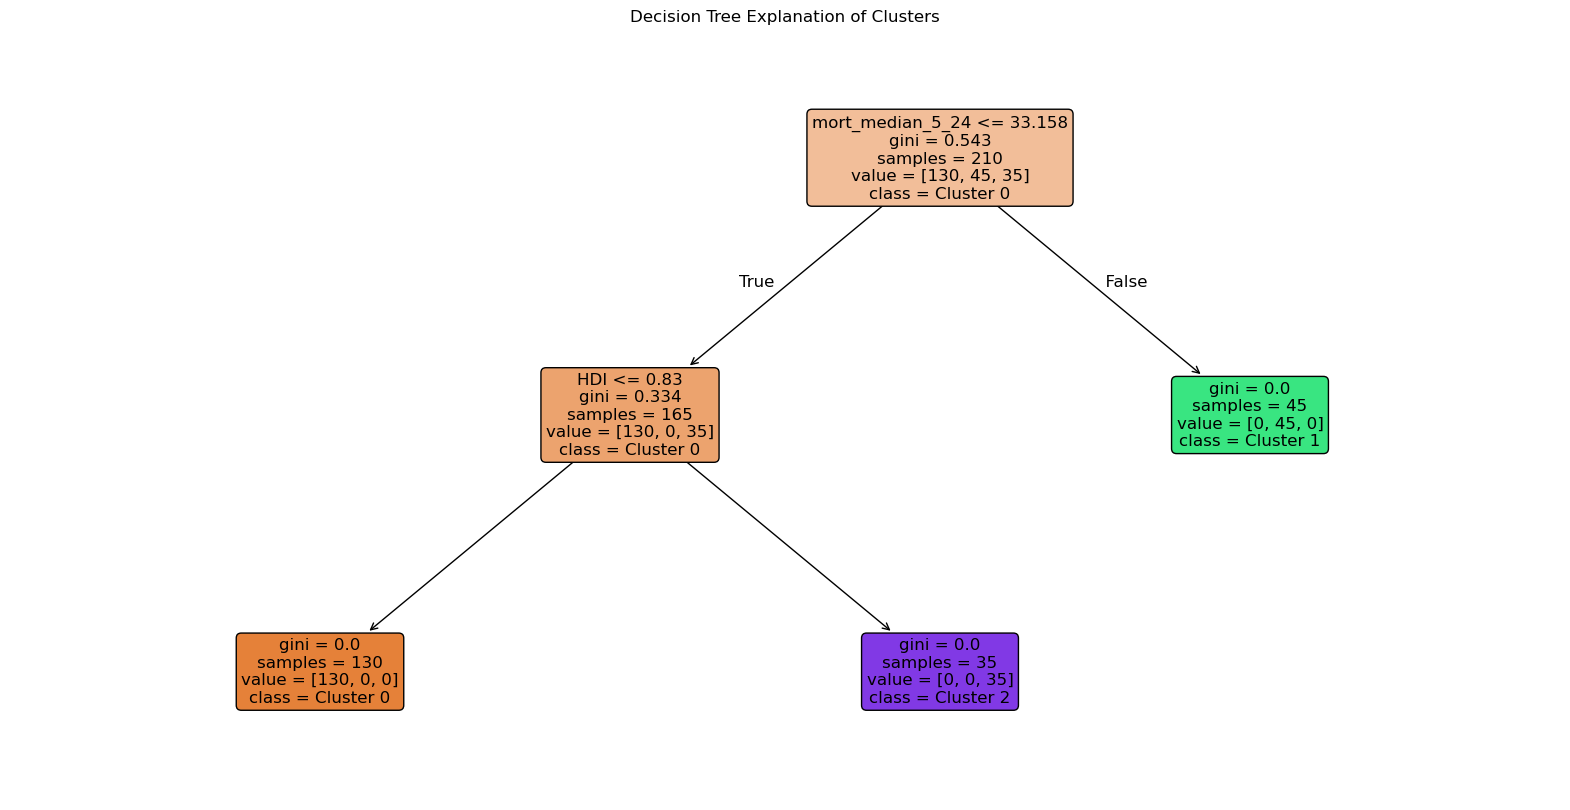

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# KMeans'te kullandığın feature'lar
features = ["HDI", "health_spending", "education_spending", "mort_median_5_24"]

X_tree = df[features]
y_tree = df["Cluster"]

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_tree, y_tree)

plt.figure(figsize=(20, 10))

plot_tree(
    clf,
    feature_names=features,
    class_names=["Cluster 0", "Cluster 1", "Cluster 2"],
    filled=True,
    rounded=True,
    fontsize=12
)

plt.title("Decision Tree Explanation of Clusters")
plt.show()

To better understand the clustering structure, a decision tree was trained to predict cluster assignments.

The tree reveals that clusters are primarily separated based on HDI thresholds, indicating that HDI is the dominant factor driving the clustering results. Other variables such as health and education spending play a relatively minor role in determining cluster membership.

This suggests that the clustering largely reflects underlying development levels rather than complex multi-dimensional patterns.

### time-based classification

In [ ]:
# ===== Additional Classification Analysis: Mortality Increase Prediction =====

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

# 1) Create yearly change variable
df_change = df.sort_values(["Region", "Year"]).copy()

df_change["mortality_change"] = df_change.groupby("Region")["mort_median_5_24"].diff()

df_change["increase_flag"] = (df_change["mortality_change"] > 0).astype(int)

df_change = df_change.dropna().reset_index(drop=True)


# 2) Feature selection
num_cols = ["HDI", "health_spending", "education_spending", "Year"]
cat_cols = ["Region"]

X = df_change[num_cols + cat_cols]
y = df_change["increase_flag"]


# 3) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# 4) Preprocessing
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first"), cat_cols)
    ]
)


# 5) Classification models
clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
    "KNN Classifier": KNeighborsClassifier(n_neighbors=5)
}


# 6) Train and compare models
rows = []
best_model_name = None
best_f1 = -1
best_pipe = None

for name, clf in clf_models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", clf)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    rows.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score": f1
    })
    
    if f1 > best_f1:
        best_f1 = f1
        best_model_name = name
        best_pipe = pipe


classification_results = pd.DataFrame(rows).sort_values("F1 Score", ascending=False)

classification_results

,Model,Accuracy,F1 Score
2,KNN Classifier,0.756098,0.166667
0,Logistic Regression,0.853659,0.000000
1,Decision Tree,0.756098,0.000000


In addition to regression and clustering, a classification task was defined to predict whether youth mortality increases from one year to the next.

A binary target variable was created based on year-to-year changes within each region. Logistic Regression, Decision Tree, and KNN classifiers were compared using accuracy and F1 score.

This analysis provides a temporal perspective on mortality dynamics, complementing the main regression and clustering results.

The confusion matrix shows that the model correctly identifies most “No increase” cases, but struggles to detect actual increases in mortality.

This is reflected in the lower recall for the “Increase” class, indicating that many true increases are misclassified.

Overall, the model performs better at identifying stable trends than sudden changes in mortality.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Year-based split
years = sorted(df["Year"].unique())
test_years = years[-5:]   # last 5 years as test

train_ts = df[~df["Year"].isin(test_years)].copy()
test_ts = df[df["Year"].isin(test_years)].copy()

features = ["Year", "HDI", "health_spending", "education_spending"]

X_train = train_ts[features]
y_train = train_ts["mort_median_5_24"]

X_test = test_ts[features]
y_test = test_ts["mort_median_5_24"]

# Models
ts_models = {
    "Linear Regression": LinearRegression(),
    "KNN Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=10))
    ])
}

ts_results = {}

for name, model in ts_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    ts_results[name] = {
        "model": model,
        "pred": pred,
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    }

# Baseline: train mean
baseline_pred = np.mean(y_train)
baseline_preds = [baseline_pred] * len(y_test)
rmse_baseline = np.sqrt(mean_squared_error(y_test, baseline_preds))

best_ts = min(ts_results, key=lambda m: ts_results[m]["RMSE"])
best_rmse = ts_results[best_ts]["RMSE"]

print(ts_results)
print("Baseline RMSE:", rmse_baseline)
print("Best model:", best_ts)

{'Linear Regression': {'model': LinearRegression(), 'pred': array([ 14.10931803,  13.47301406,  12.83671009,  12.20040612,
        11.56410214,  -7.80079303,  -8.437097  ,  -9.07340097,
        -9.70970495, -10.34600892,   8.59057202,   7.95426805,
         7.31796408,   6.68166011,   6.04535613,   7.1925308 ,
         6.55622683,   5.91992286,   5.28361888,   4.64731491,
        23.4948369 ,  22.85853293,  22.22222896,  21.58592499,
        20.94962101,  38.86826041,  38.23195643,  37.59565246,
        36.95934849,  36.32304451]), 'RMSE': np.float64(8.709422251233333), 'R2': 0.16023547507212454}, 'KNN Regression': {'model': Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsRegressor(n_neighbors=10))]), 'pred': array([11.61532845, 11.61532845, 11.61532845, 11.61532845, 11.61532845,
        7.12439959,  7.12439959,  7.12439959,  7.12439959,  7.12439959,
       12.92482175, 12.92482175, 12.92482175, 12.92482175, 12.66895629,
       14.79106453, 14.79106453, 

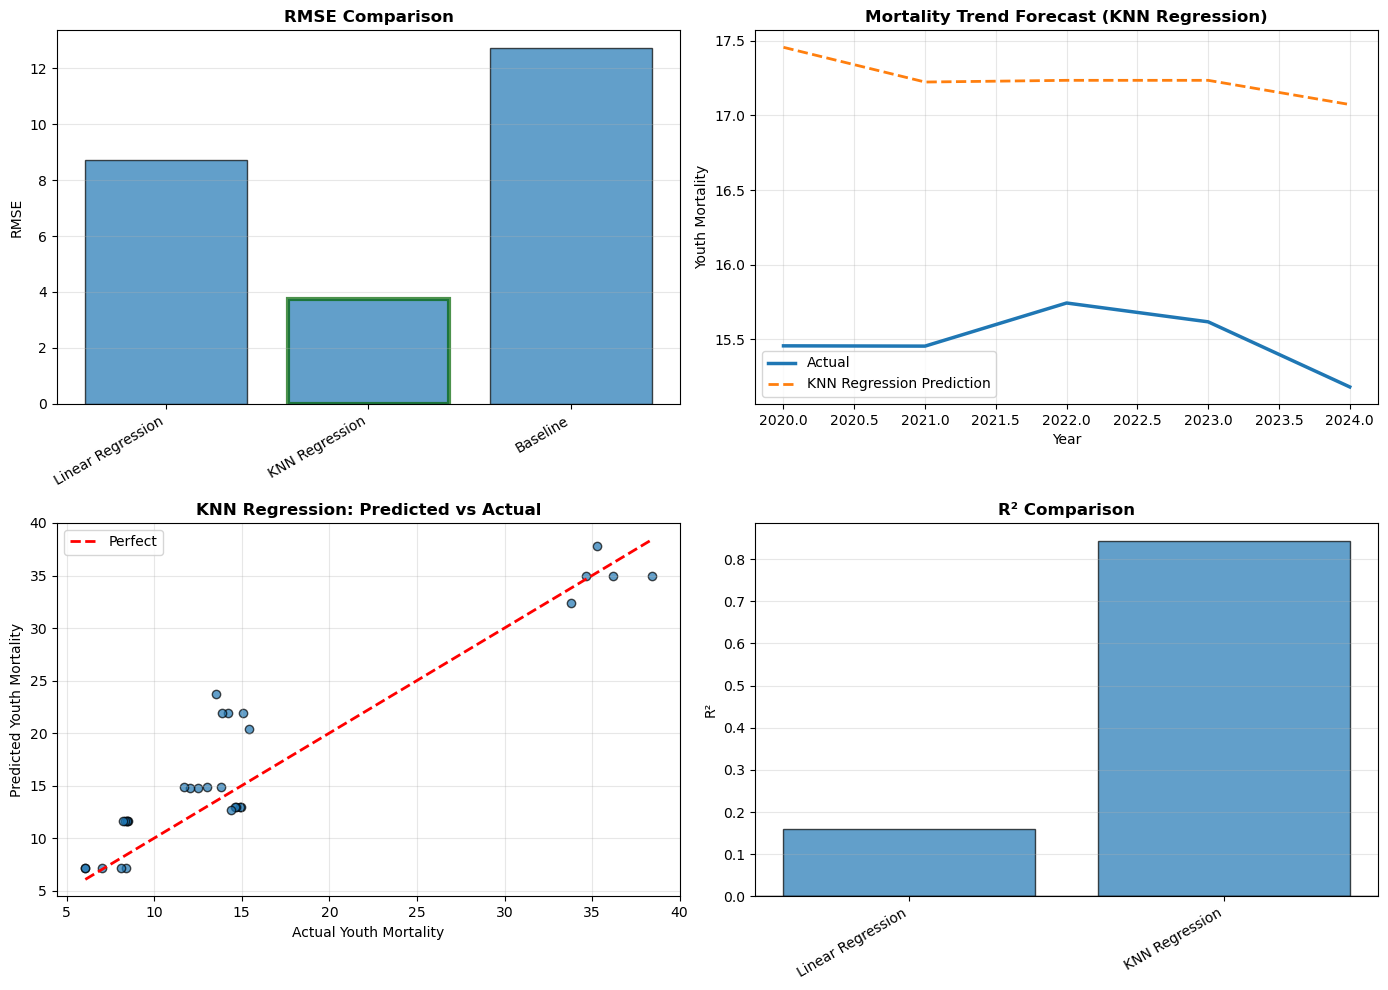

Saved: timeseries_results.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) RMSE comparison
ax = axes[0, 0]

models_ts = list(ts_results.keys()) + ["Baseline"]
rmse_vals = [ts_results[m]["RMSE"] for m in ts_results.keys()] + [rmse_baseline]

bars = ax.bar(range(len(models_ts)), rmse_vals, alpha=0.7, edgecolor="black")

best_idx = rmse_vals.index(min(rmse_vals))
bars[best_idx].set_edgecolor("darkgreen")
bars[best_idx].set_linewidth(3)

ax.set_xticks(range(len(models_ts)))
ax.set_xticklabels(models_ts, rotation=30, ha="right")
ax.set_title("RMSE Comparison", fontweight="bold")
ax.set_ylabel("RMSE")
ax.grid(alpha=0.3, axis="y")


# 2) Time trend plot
ax = axes[0, 1]

plot_df = test_ts.copy()
plot_df["Predicted"] = ts_results[best_ts]["pred"]

trend_actual = plot_df.groupby("Year")["mort_median_5_24"].mean()
trend_pred = plot_df.groupby("Year")["Predicted"].mean()

ax.plot(trend_actual.index, trend_actual.values, label="Actual", linewidth=2.5)
ax.plot(trend_pred.index, trend_pred.values, label=f"{best_ts} Prediction", linestyle="--", linewidth=2)

ax.set_title(f"Mortality Trend Forecast ({best_ts})", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Youth Mortality")
ax.legend()
ax.grid(alpha=0.3)


# 3) Predicted vs Actual
ax = axes[1, 0]

ax.scatter(y_test, ts_results[best_ts]["pred"], alpha=0.7, edgecolor="black")

min_val = min(y_test.min(), ts_results[best_ts]["pred"].min())
max_val = max(y_test.max(), ts_results[best_ts]["pred"].max())

ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Perfect")

ax.set_xlabel("Actual Youth Mortality")
ax.set_ylabel("Predicted Youth Mortality")
ax.set_title(f"{best_ts}: Predicted vs Actual", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)


# 4) R2 comparison
ax = axes[1, 1]

r2_vals = [ts_results[m]["R2"] for m in ts_results.keys()]

ax.bar(range(len(ts_results)), r2_vals, alpha=0.7, edgecolor="black")
ax.set_xticks(range(len(ts_results)))
ax.set_xticklabels(list(ts_results.keys()), rotation=30, ha="right")
ax.set_title("R² Comparison", fontweight="bold")
ax.set_ylabel("R²")
ax.axhline(0, color="black", linewidth=1)
ax.grid(alpha=0.3, axis="y")


plt.tight_layout()
plt.savefig("timeseries_results.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: timeseries_results.png")

### Time-based Analysis

To capture temporal patterns, a time-based evaluation was conducted using yearly data.

The results show that KNN regression achieves lower RMSE compared to both linear regression and a simple baseline model. 

The trend plot indicates that while the model captures general mortality levels, it struggles to reflect year-to-year fluctuations accurately, suggesting limitations in modeling temporal dynamics.

Overall, this analysis highlights that although the model performs well in static prediction, incorporating time-dependent methods may further improve performance.

## Additional Classification Analysis

In addition to predicting mortality levels, a classification task was created to examine whether youth mortality increased compared to the previous year.

The target variable `increase_flag` was defined as 1 if mortality increased from the previous year and 0 otherwise. Logistic Regression, Decision Tree, and KNN Classifier models were compared using accuracy and F1 score.

This analysis provides an additional perspective by focusing not on the level of mortality, but on whether mortality trends worsen over time.

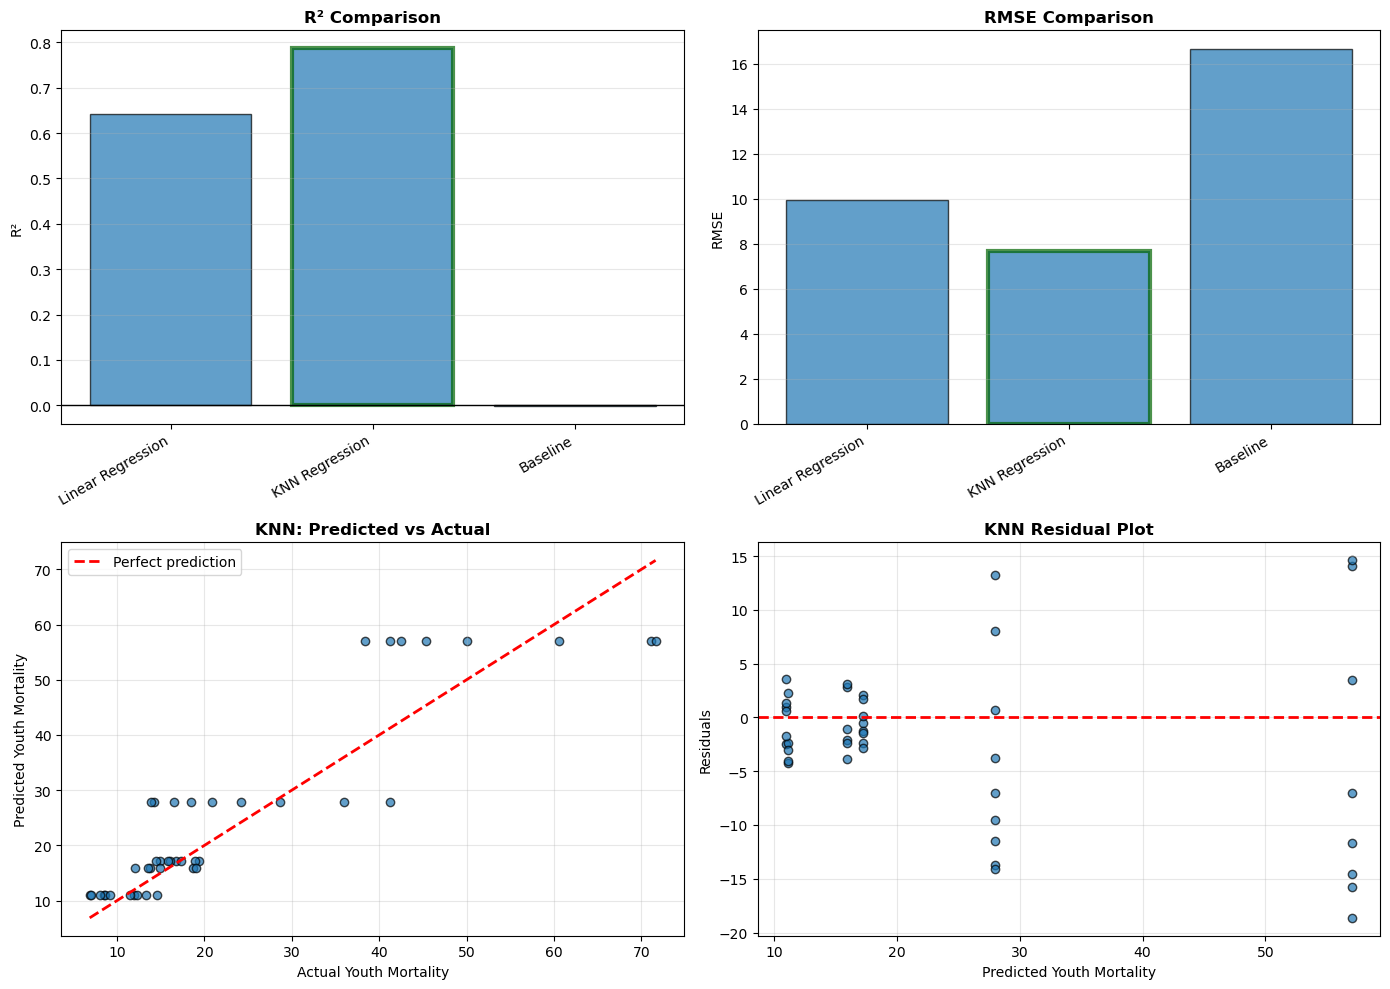

Saved: regression_results.png


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results = {
    "Linear Regression": {
        "R2_test": r2_score(y_test, y_pred_linear),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_linear))
    },
    "KNN Regression": {
        "R2_test": r2_score(y_test, y_pred_knn),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_knn))
    },
    "Baseline": {
        "R2_test": r2_score(y_test, baseline_preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, baseline_preds))
    }
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) R² comparison
ax = axes[0, 0]
models_list = list(results.keys())
r2_vals = [results[m]["R2_test"] for m in models_list]

bars = ax.bar(range(len(models_list)), r2_vals, alpha=0.7, edgecolor="black")
best_idx = r2_vals.index(max(r2_vals))
bars[best_idx].set_edgecolor("darkgreen")
bars[best_idx].set_linewidth(3)

ax.set_xticks(range(len(models_list)))
ax.set_xticklabels(models_list, rotation=30, ha="right")
ax.set_title("R² Comparison", fontweight="bold")
ax.set_ylabel("R²")
ax.axhline(0, color="black", linewidth=1)
ax.grid(alpha=0.3, axis="y")


# 2) RMSE comparison
ax = axes[0, 1]
rmse_vals = [results[m]["RMSE"] for m in models_list]

bars = ax.bar(range(len(models_list)), rmse_vals, alpha=0.7, edgecolor="black")
best_idx = rmse_vals.index(min(rmse_vals))
bars[best_idx].set_edgecolor("darkgreen")
bars[best_idx].set_linewidth(3)

ax.set_xticks(range(len(models_list)))
ax.set_xticklabels(models_list, rotation=30, ha="right")
ax.set_title("RMSE Comparison", fontweight="bold")
ax.set_ylabel("RMSE")
ax.grid(alpha=0.3, axis="y")


# 3) Predicted vs Actual - KNN
ax = axes[1, 0]

ax.scatter(y_test, y_pred_knn, alpha=0.7, edgecolor="black")

min_val = min(y_test.min(), y_pred_knn.min())
max_val = max(y_test.max(), y_pred_knn.max())

ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Perfect prediction")

ax.set_xlabel("Actual Youth Mortality")
ax.set_ylabel("Predicted Youth Mortality")
ax.set_title("KNN: Predicted vs Actual", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)


# 4) Residual plot - KNN
ax = axes[1, 1]

residuals = y_test - y_pred_knn

ax.scatter(y_pred_knn, residuals, alpha=0.7, edgecolor="black")
ax.axhline(0, color="red", linestyle="--", linewidth=2)

ax.set_xlabel("Predicted Youth Mortality")
ax.set_ylabel("Residuals")
ax.set_title("KNN Residual Plot", fontweight="bold")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("regression_results.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: regression_results.png")


KNN Regression achieved the highest R² and lowest RMSE compared to Linear Regression and the baseline model. This indicates that KNN provides better predictive performance for youth mortality.

The predicted vs actual plot shows that the model captures the general pattern, although some deviations remain. The residual plot suggests that prediction errors are larger for some observations, especially at higher mortality levels.

## Additional Time-Based Evaluation

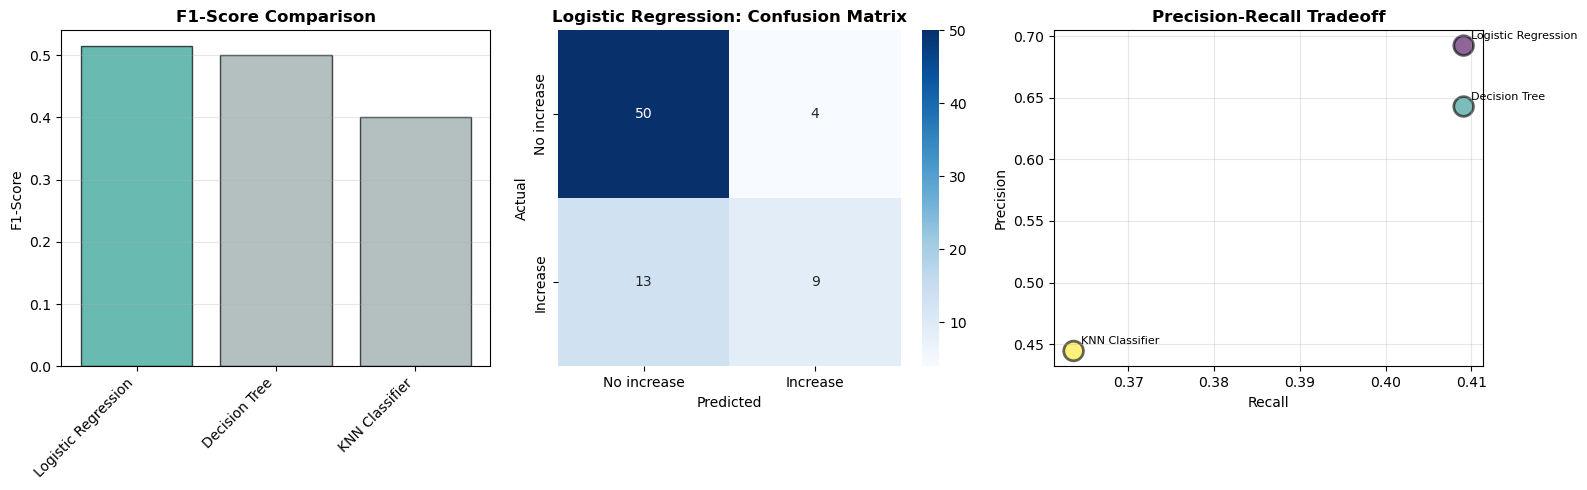

Best model: Logistic Regression
                     Accuracy Precision    Recall        F1
Logistic Regression  0.776316  0.692308  0.409091  0.514286
Decision Tree        0.763158  0.642857  0.409091       0.5
KNN Classifier       0.684211  0.444444  0.363636       0.4
Saved: classification_results.png


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1) Create classification dataset
df_change = df.sort_values(["Region", "Year"]).copy()

df_change["mortality_change"] = df_change.groupby("Region")["mort_median_5_24"].diff()
df_change["increase_flag"] = (df_change["mortality_change"] > 0).astype(int)

df_change = df_change.dropna().reset_index(drop=True)

# 2) Features and target
num_cols = ["HDI", "health_spending", "education_spending", "Year"]
cat_cols = ["Region"]

X_class = df_change[num_cols + cat_cols]
y_class = df_change["increase_flag"]

# 3) Train-test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

# 4) Preprocessing
preprocess_c = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first"), cat_cols)
    ]
)

# 5) Models
clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
    "KNN Classifier": KNeighborsClassifier(n_neighbors=5)
}

# 6) Train models
class_results = {}

for name, clf in clf_models.items():
    pipe = Pipeline([
        ("preprocess", preprocess_c),
        ("model", clf)
    ])
    
    pipe.fit(X_train_c, y_train_c)
    y_pred_c = pipe.predict(X_test_c)
    
    class_results[name] = {
        "Accuracy": accuracy_score(y_test_c, y_pred_c),
        "Precision": precision_score(y_test_c, y_pred_c, zero_division=0),
        "Recall": recall_score(y_test_c, y_pred_c, zero_division=0),
        "F1": f1_score(y_test_c, y_pred_c, zero_division=0),
        "Predictions": y_pred_c,
        "Model": pipe
    }

# 7) Best model by F1
best = max(class_results, key=lambda m: class_results[m]["F1"])
best_pred = class_results[best]["Predictions"]
cm = confusion_matrix(y_test_c, best_pred)

# 8) Plot dashboard
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# F1 comparison
ax = axes[0]
models_c = list(class_results.keys())
f1_vals = [class_results[m]["F1"] for m in models_c]

colors_c = ["#2A9D8F" if m == best else "#95a5a6" for m in models_c]

ax.bar(range(len(models_c)), f1_vals, color=colors_c, alpha=0.7, edgecolor="black")
ax.set_xticks(range(len(models_c)))
ax.set_xticklabels(models_c, rotation=45, ha="right")
ax.set_title("F1-Score Comparison", fontweight="bold")
ax.set_ylabel("F1-Score")
ax.grid(alpha=0.3, axis="y")

# Confusion matrix
ax = axes[1]

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax,
    xticklabels=["No increase", "Increase"],
    yticklabels=["No increase", "Increase"]
)

ax.set_title(f"{best}: Confusion Matrix", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

# Precision-Recall tradeoff
ax = axes[2]

recalls = [class_results[m]["Recall"] for m in models_c]
precisions = [class_results[m]["Precision"] for m in models_c]

ax.scatter(
    recalls,
    precisions,
    s=200,
    alpha=0.6,
    c=range(len(models_c)),
    cmap="viridis",
    edgecolor="black",
    linewidth=2
)

for i, m in enumerate(models_c):
    ax.annotate(
        m,
        (recalls[i], precisions[i]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Tradeoff", fontweight="bold")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("classification_results.png", dpi=300, bbox_inches="tight")
plt.show()

print("Best model:", best)
print(pd.DataFrame(class_results).T[["Accuracy", "Precision", "Recall", "F1"]])
print("Saved: classification_results.png")

The classification results show that Logistic Regression performs best among the tested models, achieving the highest F1-score. However, the recall for the “Increase” class remains relatively low, indicating that the model misses a considerable number of actual mortality increases.

The confusion matrix confirms this pattern: the model is strong at identifying “No increase” cases, but less effective at detecting actual increases. This suggests that predicting year-to-year increases in mortality is more difficult than predicting overall mortality levels and may require additional temporal or structural variables.

The KNN model outperforms both linear regression and the baseline model, achieving the lowest RMSE and highest R² score.

The predicted vs actual plot shows that most predictions align closely with the ideal diagonal, indicating a good fit.

However, the residual plot suggests increasing variance at higher predicted values, indicating potential heteroscedasticity and limitations in modeling extreme mortality values.